<a href="https://colab.research.google.com/github/melaniee-sudo/machine-learning-udg-tareas/blob/main/p4_metricas_desempe%C3%B1o_clasificadores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

#cargar base de datos Wine
wine = datasets.load_wine()

X = wine.data
y = wine.target

class_names = wine.target_names

print("Clases:", class_names)
print("Cantidad de datos:", len(y))

#Hold-out 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


#funcion para calcular especificidad en clasificación multiclase
def calcular_especificidad(cm):

    especificidades = []

    for i in range(len(cm)):

        TP = cm[i, i]
        FN = np.sum(cm[i, :]) - TP
        FP = np.sum(cm[:, i]) - TP
        TN = np.sum(cm) - TP - FN - FP

        especificidad = TN / (TN + FP)

        especificidades.append(especificidad)

    #promedio entre las 3 clases
    return np.mean(especificidades)

Clases: ['class_0' 'class_1' 'class_2']
Cantidad de datos: 178


In [8]:

iteraciones = [1, 15, 50, 100] #diferentes cantidades de iteraciones

resultados = []


for it in iteraciones:

    print("\n")
    print("=" * 55)
    print("ITERACIONES:", it)
    print("=" * 55)



    modelo = LogisticRegression(max_iter=it) #crear modelo
    modelo.fit(X_train, y_train) #entrenar

    y_pred = modelo.predict(X_test) #predicciones



ITERACIONES: 1


ITERACIONES: 15


ITERACIONES: 50


ITERACIONES: 100


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Matriz de confusión:
[[13  1  0]
 [ 0 14  0]
 [ 0  0  8]]


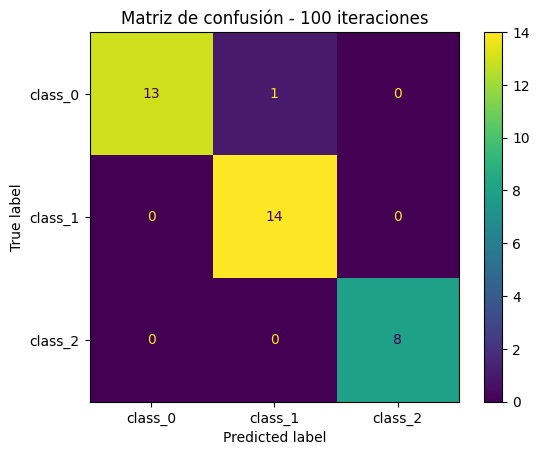

In [9]:
    #matriz de confusion
    cm = confusion_matrix(y_test, y_pred)

    print("\nMatriz de confusión:")
    print(cm)

    ConfusionMatrixDisplay(
        cm,
        display_labels=class_names
    ).plot(cmap="viridis")

    plt.title(
        "Matriz de confusión - "
        + str(it)
        + " iteraciones"
    )

    plt.show()

In [11]:
    #metricas
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    especificidad = calcular_especificidad(cm)


    print("\nAccuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Especificidad:", especificidad)
    print("F1-Score:", f1)


    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )


Accuracy: 0.9722222222222222
Precision: 0.9777777777777779
Recall: 0.9761904761904763
Especificidad: 0.9848484848484849
F1-Score: 0.9761600681140911

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      0.93      0.96        14
     class_1       0.93      1.00      0.97        14
     class_2       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



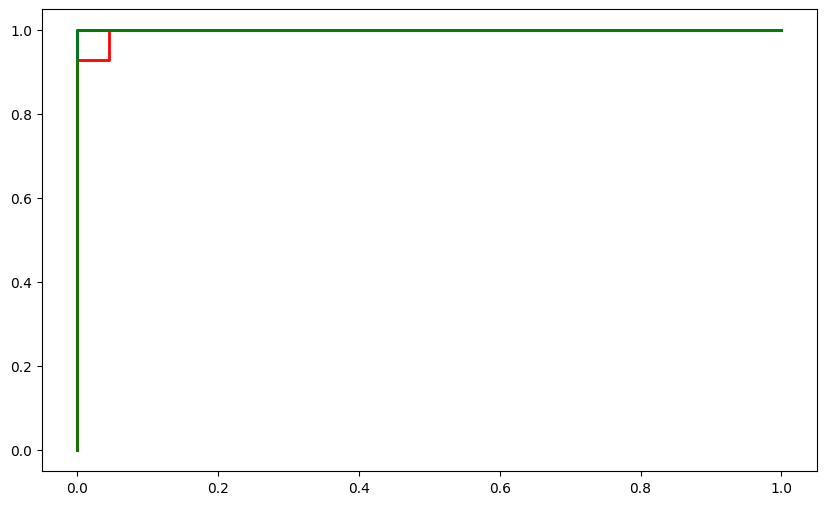

In [14]:
# ROC - AUC
y_test_bin = label_binarize(
    y_test,
    classes=[0, 1, 2]
)

n_classes = y_test_bin.shape[1]

y_score = modelo.predict_proba(X_test)

plt.figure(figsize=(10, 6))

colors = ["blue", "red", "green"]

auc_clases = []

for i, color in zip(range(n_classes), colors):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    auc_clases.append(roc_auc)

    plt.plot(
        fpr,
        tpr,
        color=color,
        lw=2,
        label=(
            "ROC "
            + class_names[i]
            + " (AUC = "
            + format(roc_auc, ".3f")
            + ")"
        )
    )

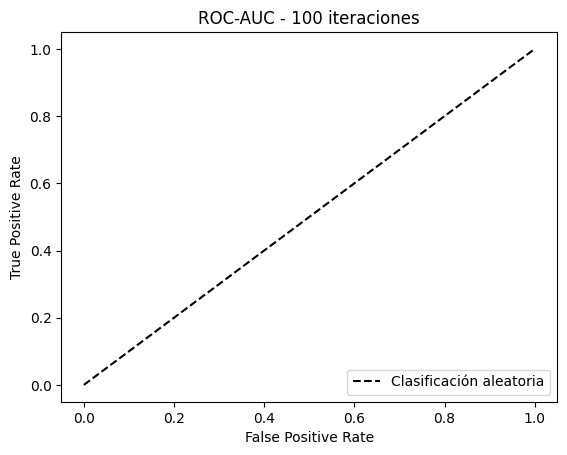

In [15]:
#linea de referencia
plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Clasificación aleatoria"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC-AUC - "
    + str(it)
    + " iteraciones"
)

plt.legend(loc="lower right")

plt.show()


auc_promedio = np.mean(auc_clases)

#guardar resultados
resultados.append({


    "Iteraciones": it,

    "Accuracy":
        accuracy,

    "Precision":
        precision,

    "Recall":
        recall,

    "Especificidad":
        especificidad,

    "F1-Score":
        f1,

    "AUC promedio":
        auc_promedio

})


In [16]:
tabla_resultados = pd.DataFrame(
    resultados
)

print("\nRESULTADOS FINALES")

print(
    tabla_resultados.round(4)
)


RESULTADOS FINALES
   Iteraciones  Accuracy  Precision  Recall  Especificidad  F1-Score  \
0          100    0.9722     0.9778  0.9762         0.9848    0.9762   

   AUC promedio  
0        0.9989  
